# Problem 1.5

Using a constrained optimizer: <br> 
Now we add constraints to Prob. 1.4. The objective is the same, but we now have two inequality constraints: <br>

x1^2 + x2^2 - 1 <= 0 <br>
-x1 + 3*x2 - 1/2 <= 0 <br>

and bound constraints: <br>

x1 >= 0, x2 >= 0. <br>

Plot the constraints and identify the feasible region. Find the constrained minimum graphically. Use optimization software to solve the constrained minimization problem. Which of the inequality constraints and bounds are active at the solution?

In [38]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Approach

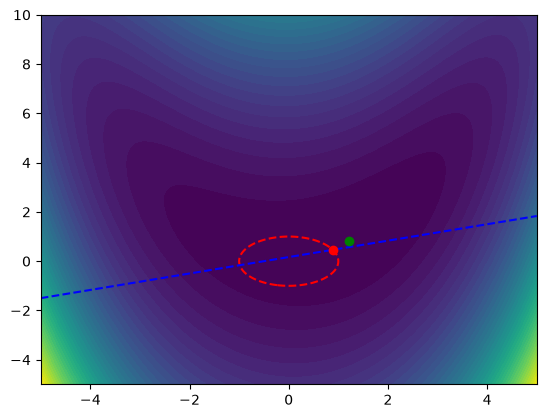

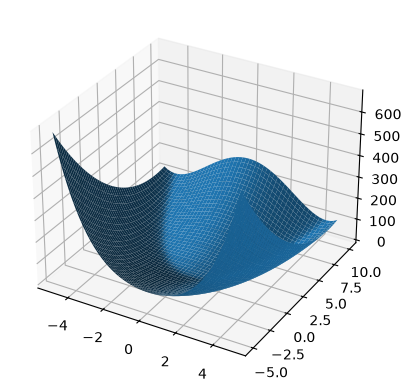

In [39]:
# define the function
def func(x):
    return (1 - x[0])**2 + (1 - x[1])**2 + 0.5*(2*x[1] - x[0]**2)**2

def con1(x): # inequality constraint 1
    return x[0]**2 + x[1]**2 - 1

def con2(x): # inequality constraint 2
    return - x[0] + 3*x[1]  - 0.5

# make data
X1, X2 = np.meshgrid(np.linspace(-5, 5, 500), np.linspace(-5, 10, 500))
Z = func([X1, X2])
C1 = con1([X1, X2])
C2 = con2([X1, X2])
levels = np.linspace(np.min(Z), np.max(Z), 45)

# plot
fig1, ax1 = plt.subplots()
ax1.contourf(X1, X2, Z, levels=levels)
ax1.contour(X1, X2, C1, levels=[0], colors='red', linestyles='dashed')
ax1.contour(X1, X2, C2, levels=[0], colors='blue', linestyles='dashed')
ax1.plot(1.213, 0.824,'o', color='green') # true minimum
ax1.plot(0.887, 0.462,'o', color='red') # constrained minimum
#ax1.plot(0.7, 0.6,'o', color='yellow') # approximate minimum  constraints

fig2, ax2 = plt.subplots(subplot_kw={"projection": "3d"})
ax2.plot_surface(X1, X2, Z, vmin=Z.min())

plt.show()

In [41]:
ineq_cons = {'type': 'ineq',
             'fun' : lambda x: np.array([-x[0]**2 - x[1]**2 + 1,
                                         x[0] - 3*x[1] + 0.5])}
bounds = ((0, None), (0, None))

x0 = np.array([5, -5])
res = minimize(func, x0, method='SLSQP',
               constraints=[ineq_cons], options={'ftol': 1e-9, 'disp': True},
               bounds=bounds)
print(f"Minimum found at: x1 = {res.x[0]:.3f}, x2 = {res.x[1]:.3f} using SLSQP method" )

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.3115469339412655
            Iterations: 9
            Function evaluations: 28
            Gradient evaluations: 9
Minimum found at: x1 = 0.887, x2 = 0.462 using SLSQP method


## Results

the feasable region is now reduced by two inequality constraints and two bound constraints. the first constraint is a circle that restricts the region to the inside of the circle. the second is a line that restricts the feasable region it to the part below it. the bounds specify that x1 and x2 must be positive or 0. the feasable region now excludes the global optimum. as such when the SLSQP optimizer is run it converges to a different optimum inside the feasable region at [0.887, 0.462]. at that minimum both inequality constraints are active but the bounds arent. when the startpoint is set outside the feasable region it still converges to the new optimum inside the feasable region, this shows how the optimizer can deal with diffiult starting conditions.

## Interpretation

the resutls show how the constraints move the optimum. this is a fundamental part of optimization. in real systems there are always bounds and constraints that limit the optimal design. finding out which constraints currently limit the design from a better optimum and modifying them to improve the product is the core loop oft MDO.